<a href="https://colab.research.google.com/github/Antoine99s/bank-churn-predictor/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Bank_Churn.csv')
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())

(10000, 13)
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
0


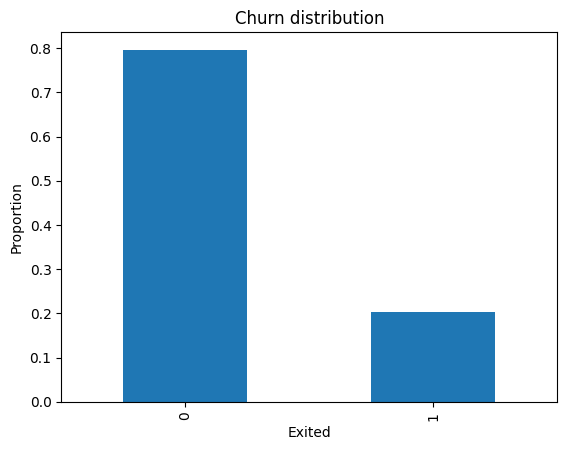

In [ ]:
df['Exited'].value_counts(normalize=True).plot(kind='bar')
plt.title('Churn distribution')
plt.ylabel('Proportion')
plt.show()
#Plot data to show only 20% churn rate within dataset

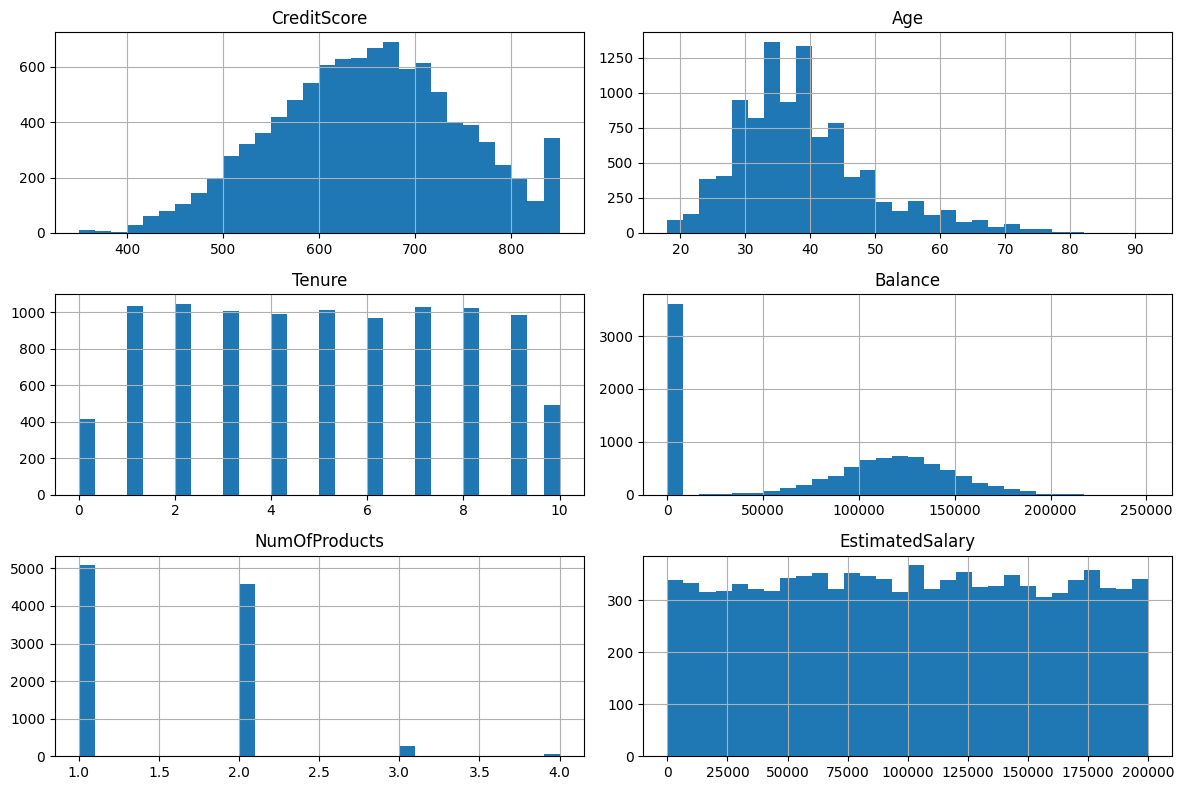

In [ ]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
df[num_cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()
#more data visualization

In [ ]:
for col in ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']:
    churn_rate = df.groupby(col)['Exited'].mean()
    print(churn_rate)
    print('---')
    #churn rate by categorical features

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64
---
Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64
---
HasCrCard
0    0.208149
1    0.201843
Name: Exited, dtype: float64
---
IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64
---
NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64
---


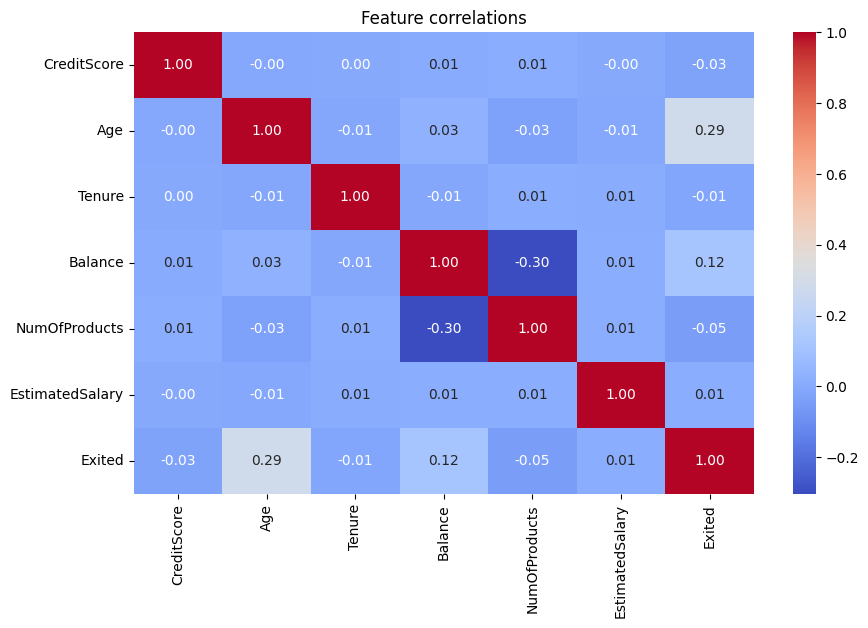

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols + ['Exited']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature correlations')
plt.show()
#correlation heatmap

In [ ]:
zero_balance_customers = df[df['Balance'] == 0]
percentage_zero_balance = (len(zero_balance_customers) / len(df)) * 100
print(f"Percentage of customers with zero balance: {percentage_zero_balance:.2f}%")


Percentage of customers with zero balance: 36.17%


In [ ]:
df['NumOfProducts'].value_counts()

,count
NumOfProducts,
1,5084
2,4590
3,266
4,60
